Fix a matrix A. Choose eigenvalues to be all distinct. Find Lambda_A, Q_A

Fix an orientation vector k

Loop through different (small pos. angles theta). Generate K (from k) and hence R = exp(theta K)

Since R = Q_A Q_B^T, form Q_B =Q_A R^T. 

Consider different cases. If Lambda_B are distinct, form B= Q_B Lamba_B Q_B^T

Then look what happens as Lambda_B varies as theta varies.



In [1]:
from time import time
import numpy as np
import os
import sys
from matplotlib import pyplot as plt
from scipy.stats import ortho_group
# include the src path
sys.path.insert(0, "src")
from EigenValueDecomposition import *
from MinMaxthetafromQRQI import *
from SortEigenValues import *
from AnglesSortedQRQI import *
from SplitTensor import *
from Fmeasure import *
from Commeasure import *
import scipy as sci

In [2]:
# Fixed symmetric A
A=np.array([[3,1,0.5],[1,4,0.25],[0.5,0.25,5]])
print(A)
LambdaA,QA=np.linalg.eig(A)

# Orientation vector
k =np.array([1,0,0])
K =np.array([[0,-k[2],k[1]],[k[2],0,-k[0]],[-k[1],k[0],0]])


[[3.   1.   0.5 ]
 [1.   4.   0.25]
 [0.5  0.25 5.  ]]


In [3]:
# Fix number of cases to be considered and fix some eigenvalues.
MultR=[1,1,1]
MultI=[1,1,1]
MultRtilde=[1,1,1]

Theta=np.logspace(-2,-1,100)
print(Theta)
N=len(Theta)

N0=np.zeros((3,3))
Rstore=np.zeros((N,9))
Istore=np.zeros((N,9))
Mlist=np.zeros(9, dtype=complex)
TensorArray=np.zeros((N,9),dtype=complex)
Frequencies=np.zeros(N)
URstore=np.zeros((N,3))
UIstore=np.zeros((N,3))
URtildestore=np.zeros((N,3))
QRstore=np.zeros((N,3,3))
QIstore=np.zeros((N,3,3))
QRtildestore=np.zeros((N,3,3))
MultRstore=np.zeros(N)
MultIstore=np.zeros(N)
MultRtildestore=np.zeros(N)


[0.01       0.01023531 0.01047616 0.01072267 0.01097499 0.01123324
 0.01149757 0.01176812 0.01204504 0.01232847 0.01261857 0.0129155
 0.01321941 0.01353048 0.01384886 0.01417474 0.01450829 0.01484968
 0.01519911 0.01555676 0.01592283 0.01629751 0.01668101 0.01707353
 0.01747528 0.0178865  0.01830738 0.01873817 0.0191791  0.01963041
 0.02009233 0.02056512 0.02104904 0.02154435 0.02205131 0.0225702
 0.0231013  0.02364489 0.02420128 0.02477076 0.02535364 0.02595024
 0.02656088 0.02718588 0.02782559 0.02848036 0.02915053 0.02983647
 0.03053856 0.03125716 0.03199267 0.03274549 0.03351603 0.03430469
 0.03511192 0.03593814 0.0367838  0.03764936 0.03853529 0.03944206
 0.04037017 0.04132012 0.04229243 0.04328761 0.04430621 0.04534879
 0.04641589 0.0475081  0.04862602 0.04977024 0.05094138 0.05214008
 0.05336699 0.05462277 0.0559081  0.05722368 0.05857021 0.05994843
 0.06135907 0.06280291 0.06428073 0.06579332 0.06734151 0.06892612
 0.07054802 0.07220809 0.07390722 0.07564633 0.07742637 0.079248

In [4]:



# Choose angles
for n in range(len(Theta)):
    theta =Theta[n]
    R=sci.linalg.expm(theta*K)
    R=R/np.linalg.norm(R)
    print(R)
    print(R@R.T)
    print(np.linalg.norm(R))

    QB=QA@R.T
    # Set LambdaB=LambdaA for now
    LambdaB=LambdaA
    B=QB@np.diag(LambdaB)@QB.T

    
    uR=LambdaA
    VR=QA
    VRtilde=VR
    VI=QB
    uRtilde=uR
    uI=LambdaB
    R=A
    I=B

# Obtain the corresponding R and I
    Rtilde=R+N0
    M=Rtilde+1j*I
    Mlist[0]=M[0,0]
    Mlist[1]=M[0,1]
    Mlist[2]=M[0,2]
    Mlist[3]=M[1,0]
    Mlist[4]=M[1,1]
    Mlist[5]=M[1,2]
    Mlist[6]=M[2,0]
    Mlist[7]=M[2,1]
    Mlist[8]=M[2,2]
    for i in range(9):
        TensorArray[n,i]=Mlist[i]
# We cannot use eig to compute eigenvalues from eig since eigenvalues are placed close together!
    MultRstore[n] = np.max(MultR)
    MultIstore[n] = np.max(MultI)
    MultRtildestore[n] = np.max(MultRtilde)
    for i in range(3):
        URstore[n,i]=uR[i]
        UIstore[n,i]=uI[i]
        URtildestore[n,i]=uRtilde[i]

        for j in range(3):
            QRstore[n,i,j]=VR[i,j]
            QIstore[n,i,j]=VI[i,j]
            QRtildestore[n,i,j]=VRtilde[i,j]
# Frequencies used as dummy array to store angles            
Frequencies=Theta
            
Rstore,Istore,Rtildestore, N0store = SplitTensor(TensorArray,Frequencies,N0)            
            
# Determine eigenvalue decompositions of N0, R, I, Rtilde (no sorting applied), and their multiplicities
MultRstore, MultIstore, MultRtildestore, MultN0store, URstore, UIstore, URtildestore, UN0store, QRstore, QIstore, QRtildestore, QN0store = EigenValueDecomposition(N0,TensorArray,Frequencies)

# Determine the maximal and minimal angles from QR and QI also output d_F metric for these orderings
FixEvecs="Yes"#"Yes"
MinAnglestoreRI, MaxAnglestoreRI, dFMinAnglestoreRI, dFMaxAnglestoreRI,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = MinMaxthetafromQRQI(Frequencies,QRstore,QIstore,URstore, UIstore,MultRstore,MultIstore,FixEvecs)
SortedMultRstore=[]
SortedMultIstore=[]

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is maximal
sorteigenvalues="MaxDifference"
SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)

# Obtain angles for this sorted min-max combination
AnglestoreRIsortedmaxdiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
AnglestoreRIfmeasfullconstsortedmaxdiff, AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmaxdiff_max, RIfmeasapprx_den_const_max = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
AnglestoreRIcommeasfullconstsortedmaxdiff, AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmaxdiff_max, RIcommeapprx_den_const_max = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is minimal
sorteigenvalues="MinDifference"
SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)
# Obtain angles for this sorted min-max combination
AnglestoreRIsortedmindiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
AnglestoreRIfmeasfullconstsortedmindiff, AnglestoreRIfmeasapprxconstsortedmindiff_min, AnglestoreRIfmeasapprxconstsortedmindiff_max, RIfmeasapprx_den_const_min = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
AnglestoreRIcommeasfullconstsortedmindiff, AnglestoreRIcommeasapprxconstsortedmindiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_max, RIcommeapprx_den_const_min = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)


[[ 0.57735027  0.          0.        ]
 [ 0.          0.5773214  -0.00577341]
 [ 0.          0.00577341  0.5773214 ]]
[[ 3.33333333e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  3.33333333e-01 -1.87640281e-19]
 [ 0.00000000e+00 -1.87640281e-19  3.33333333e-01]]
1.0
[[ 0.57735027  0.          0.        ]
 [ 0.          0.57732003 -0.00590926]
 [ 0.          0.00590926  0.57732003]]
[[3.33333333e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.33333333e-01 1.80023411e-20]
 [0.00000000e+00 1.80023411e-20 3.33333333e-01]]
1.0
[[ 0.57735027  0.          0.        ]
 [ 0.          0.57731859 -0.0060483 ]
 [ 0.          0.0060483   0.57731859]]
[[3.33333333e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.33333333e-01 8.65523247e-20]
 [0.00000000e+00 8.65523247e-20 3.33333333e-01]]
1.0
[[ 0.57735027  0.          0.        ]
 [ 0.          0.57731708 -0.00619062]
 [ 0.          0.00619062  0.57731708]]
[[ 3.33333333e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  3.

/Users/paulledger/Coding/Rodrigues_angles/Rodrigues_Angles/src/StableAngle.py:10: RuntimeWarning: invalid value encountered in arccos
  theta = np.arccos((np.trace(Q)-1.)/2.)


logm result may be inaccurate, approximate err = 4.500668304841e-12


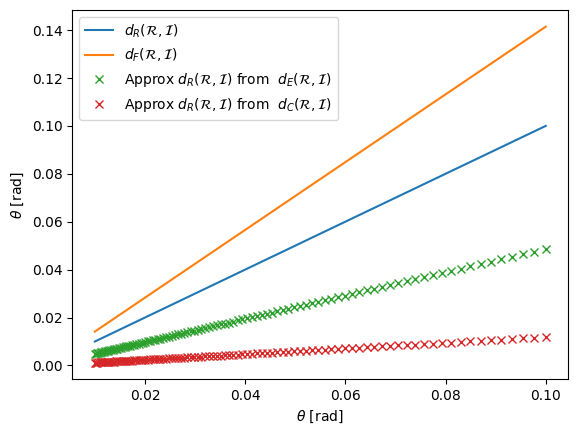

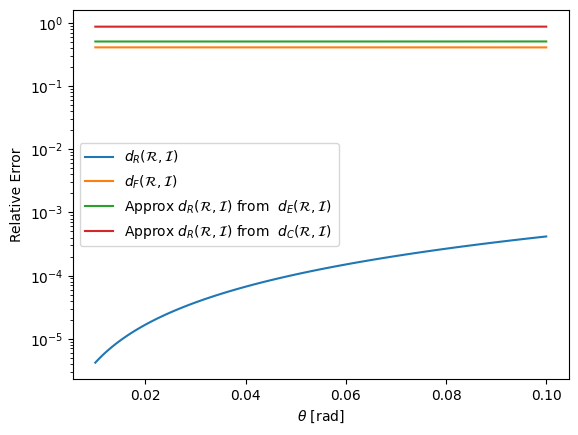

In [5]:
#print(MinAnglestoreRI,dFMinAnglestoreRI)
#print(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min))
#print(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min))

plt.plot(Frequencies,MinAnglestoreRI,label=r'$d_R({\cal R},{\cal I})$')
plt.plot(Frequencies,dFMinAnglestoreRI,label=r'$d_F({\cal R},{\cal I})$')
plt.plot(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')

        #plt.semilogx(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_max,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
plt.plot(Frequencies,np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')

plt.xlabel(r'$\theta$ [rad]')
plt.ylabel(r'$\theta$ [rad]')
plt.legend()
plt.show()

plt.semilogy(Frequencies,abs(MinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_R({\cal R},{\cal I})$')
plt.semilogy(Frequencies,abs(dFMinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_F({\cal R},{\cal I})$')
plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')

        #plt.semilogx(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_max,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')

plt.xlabel(r'$\theta$ [rad]')
plt.ylabel(r'Relative Error')
plt.legend()
plt.show()




In [43]:
# Fix an angle theta =0.1 say and loop through different cases of eigenvalues

# 
A=np.array([[3,1,0.5],[1,4,0.25],[0.5,0.25,5]])
print(A)
LambdaA,QA=np.linalg.eig(A)
LambdaA=[1,2,3]
QA=np.eye(3)
A=QA@np.diag(LambdaA)@QA.T
ThetaChoice=0.001
Theta=np.logspace(-3,-1,100)
for n in range(len(Theta)):
    
    #A=np.array([[3,1,0.5],[1,4,0.25],[0.5,0.25,5]])
    #QA=np.eye(3)
    # Update LambdaA
    #LambdaA=[1,1.5,2]
    #A=QA@np.diag(LambdaA)@QA.T
    theta =ThetaChoice
    R=sci.linalg.expm(theta*K)
    R=R/np.linalg.norm(R)

    QB=QA@R.T
    # fix two eigenvalues, let one be close lambda_1
    LambdaB=[1,1+Theta[n],2]
    B=QB@np.diag(LambdaB)@QB.T

    
    uR=LambdaA
    VR=QA
    VRtilde=VR
    VI=QB
    uRtilde=uR
    uI=LambdaB
    R=A
    I=B

# Obtain the corresponding R and I
    Rtilde=R+N0
    M=Rtilde+1j*I
    Mlist[0]=M[0,0]
    Mlist[1]=M[0,1]
    Mlist[2]=M[0,2]
    Mlist[3]=M[1,0]
    Mlist[4]=M[1,1]
    Mlist[5]=M[1,2]
    Mlist[6]=M[2,0]
    Mlist[7]=M[2,1]
    Mlist[8]=M[2,2]
    for i in range(9):
        TensorArray[n,i]=Mlist[i]
# We cannot use eig to compute eigenvalues from eig since eigenvalues are placed close together!
    MultRstore[n] = np.max(MultR)
    MultIstore[n] = np.max(MultI)
    MultRtildestore[n] = np.max(MultRtilde)
    for i in range(3):
        URstore[n,i]=uR[i]
        UIstore[n,i]=uI[i]
        URtildestore[n,i]=uRtilde[i]

        for j in range(3):
            QRstore[n,i,j]=VR[i,j]
            QIstore[n,i,j]=VI[i,j]
            QRtildestore[n,i,j]=VRtilde[i,j]
# Frequencies used as dummy array to store angles            
Frequencies=Theta
            
Rstore,Istore,Rtildestore, N0store = SplitTensor(TensorArray,Frequencies,N0)            
            
# Determine eigenvalue decompositions of N0, R, I, Rtilde (no sorting applied), and their multiplicities
MultRstore, MultIstore, MultRtildestore, MultN0store, URstore, UIstore, URtildestore, UN0store, QRstore, QIstore, QRtildestore, QN0store = EigenValueDecomposition(N0,TensorArray,Frequencies)

# Determine the maximal and minimal angles from QR and QI also output d_F metric for these orderings
FixEvecs="Yes"#"Yes"
MinAnglestoreRI, MaxAnglestoreRI, dFMinAnglestoreRI, dFMaxAnglestoreRI,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = MinMaxthetafromQRQI(Frequencies,QRstore,QIstore,URstore, UIstore,MultRstore,MultIstore,FixEvecs)
SortedMultRstore=[]
SortedMultIstore=[]

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is maximal
sorteigenvalues="MaxDifference"
SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)

# Obtain angles for this sorted min-max combination
AnglestoreRIsortedmaxdiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
AnglestoreRIfmeasfullconstsortedmaxdiff, AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmaxdiff_max, RIfmeasapprx_den_const_max = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
AnglestoreRIcommeasfullconstsortedmaxdiff, AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmaxdiff_max, RIcommeapprx_den_const_max = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is minimal
sorteigenvalues="MinDifference"
SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)
# Obtain angles for this sorted min-max combination
AnglestoreRIsortedmindiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
AnglestoreRIfmeasfullconstsortedmindiff, AnglestoreRIfmeasapprxconstsortedmindiff_min, AnglestoreRIfmeasapprxconstsortedmindiff_max, RIfmeasapprx_den_const_min = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
AnglestoreRIcommeasfullconstsortedmindiff, AnglestoreRIcommeasapprxconstsortedmindiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_max, RIcommeapprx_den_const_min = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)


[[3.   1.   0.5 ]
 [1.   4.   0.25]
 [0.5  0.25 5.  ]]


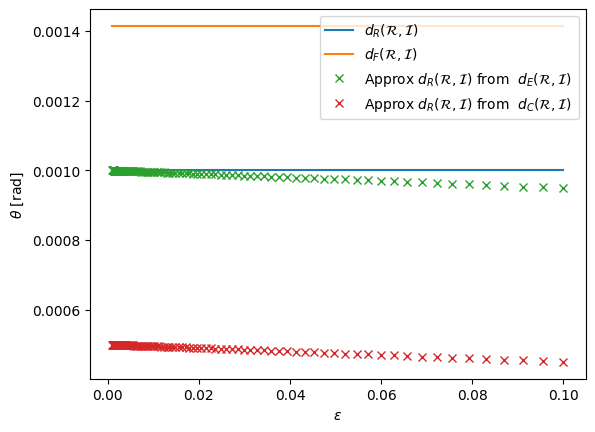

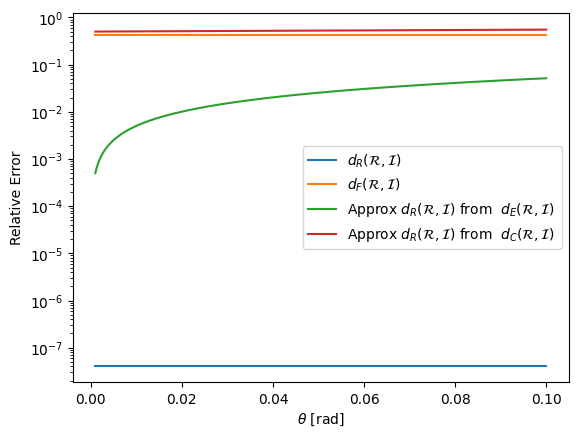

In [44]:
plt.plot(Frequencies,MinAnglestoreRI,label=r'$d_R({\cal R},{\cal I})$')
plt.plot(Frequencies,dFMinAnglestoreRI,label=r'$d_F({\cal R},{\cal I})$')
plt.plot(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')

        #plt.semilogx(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_max,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
plt.plot(Frequencies,np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')

plt.xlabel(r'$\epsilon$ ')
plt.ylabel(r'$\theta$ [rad]')
plt.legend()
plt.show()

plt.semilogy(Frequencies,abs(MinAnglestoreRI-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'$d_R({\cal R},{\cal I})$')
plt.semilogy(Frequencies,abs(dFMinAnglestoreRI-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'$d_F({\cal R},{\cal I})$')
plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')

#plt.semilogy(Frequencies,abs(MinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_R({\cal R},{\cal I})$')
#plt.semilogy(Frequencies,abs(dFMinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_F({\cal R},{\cal I})$')
#plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
#plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')


plt.xlabel(r'$\theta$ [rad]')
plt.ylabel(r'Relative Error')
plt.legend()
plt.show()
